In [6]:
import numpy as np
import pandas as pd

In [7]:
df=pd.read_csv("NYC.csv")

In [8]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [9]:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [10]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
# Create missingness indicator
df['reviews_missing'] = df['reviews_per_month'].isna().astype(int)

print(df['reviews_missing'].value_counts())

reviews_missing
0    38843
1    10052
Name: count, dtype: int64


In [13]:
print(
    df.groupby('reviews_missing')[['price',
                                    'minimum_nights',
                                    'number_of_reviews',
                                    'availability_365']].mean()
)

                      price  minimum_nights  number_of_reviews  \
reviews_missing                                                  
0                142.317947        5.868059          29.297557   
1                192.919021       11.519797           0.000000   

                 availability_365  
reviews_missing                    
0                      114.882888  
1                      104.660466  


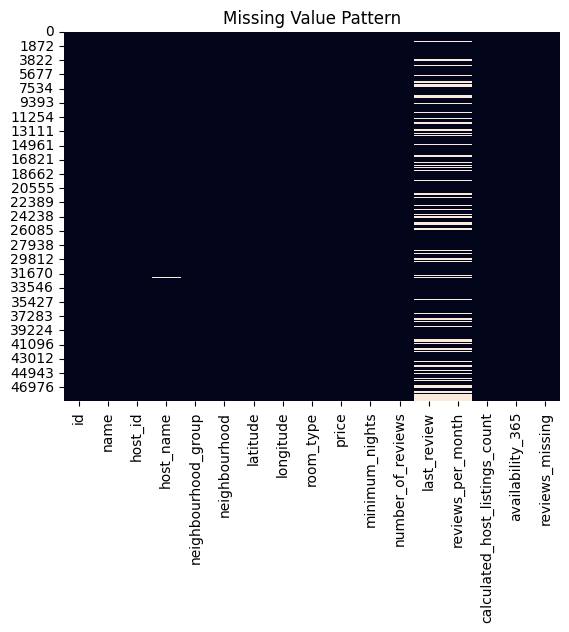

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Value Pattern")
plt.show()

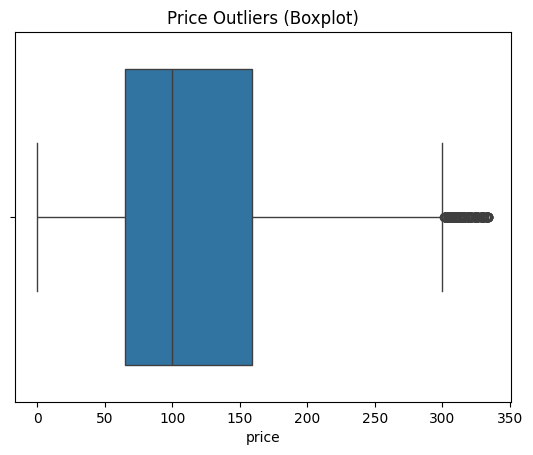

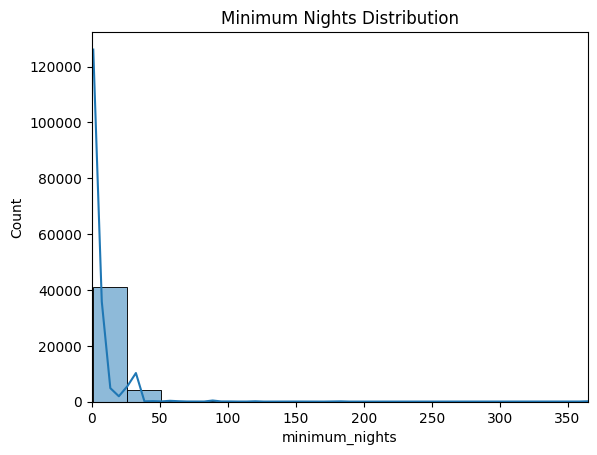

In [20]:
# Boxplot for price
sns.boxplot(x=df['price'])
plt.title("Price Outliers (Boxplot)")
plt.show()

# Histogram for minimum nights
sns.histplot(df['minimum_nights'], bins=50, kde=True)
plt.title("Minimum Nights Distribution")
plt.xlim(0, 365)  # limit to realistic values
plt.show()


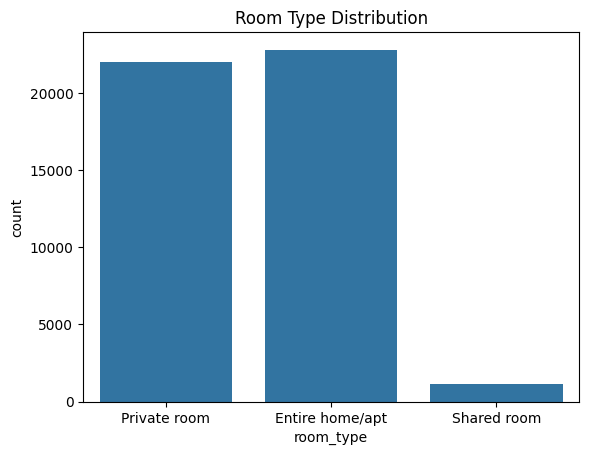

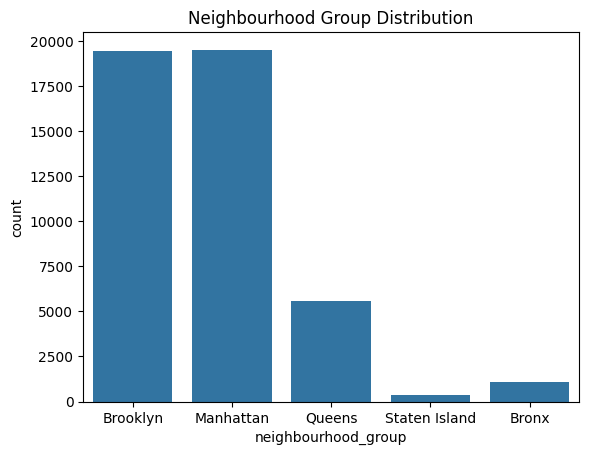

In [21]:
# Countplot for room type
sns.countplot(x=df['room_type'])
plt.title("Room Type Distribution")
plt.show()

# Countplot for neighbourhood group
sns.countplot(x=df['neighbourhood_group'])
plt.title("Neighbourhood Group Distribution")
plt.show()


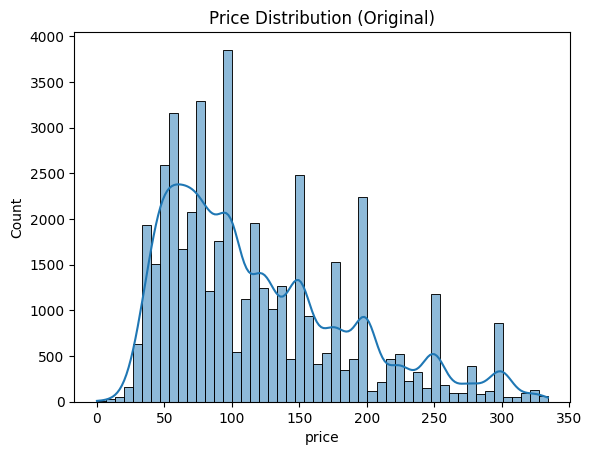

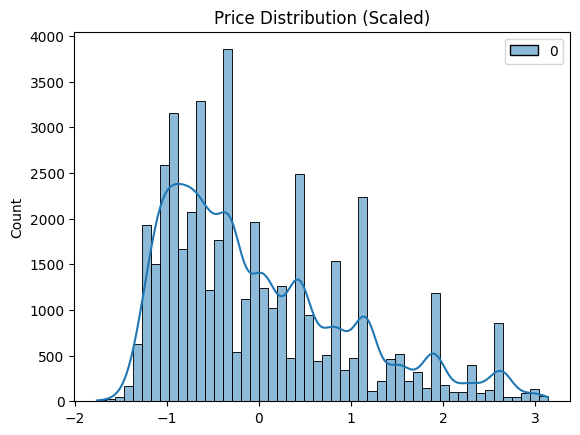

In [23]:
from sklearn.preprocessing import StandardScaler

# Original distribution
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Price Distribution (Original)")
plt.show()

# After scaling
scaler = StandardScaler()
scaled_price = scaler.fit_transform(df[['price']])

sns.histplot(scaled_price, bins=50, kde=True)
plt.title("Price Distribution (Scaled)")
plt.show()


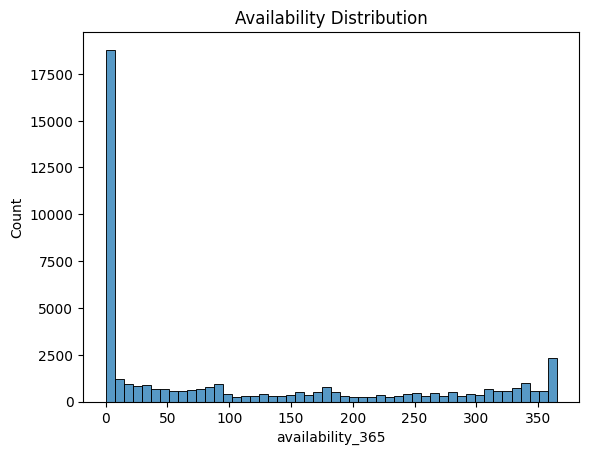

In [26]:
# Histogram for availability
sns.histplot(df['availability_365'], bins=50, kde=False)
plt.title("Availability Distribution")
plt.show()


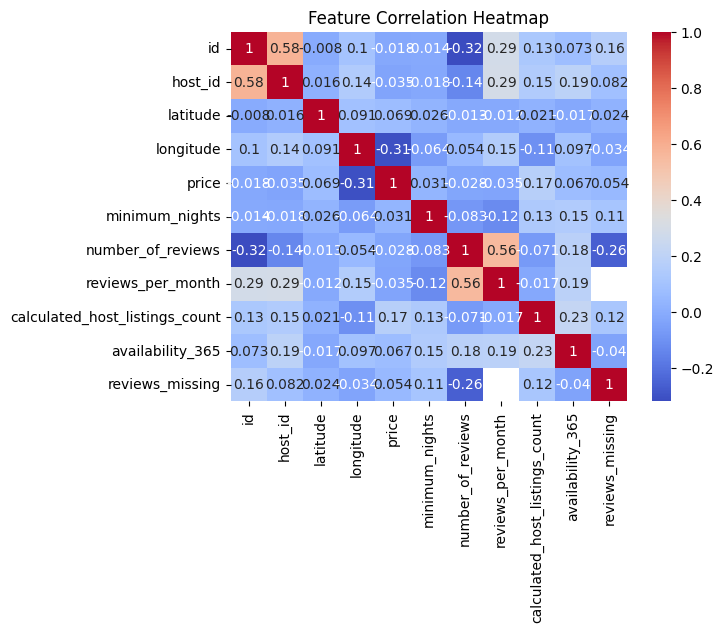

In [31]:
# Correlation heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()
